Time-Series Sales Forecasting Analysis using ARIMA , SARIMA , Prophet and LSTM.

Problem Statement :-

Their aim is to analyze historical sales data to derive business insights and forecast future demand.

Mainly we concentrate on:

Finding sales patterns for different times and customer groups.

Seasonality and outliers in the daily sales.

Forecasting Sales for the Next Week with ARIMA, Prophet, LSTM and SARIMA

Comparing the performance of models and advising on operational decisions.

Dataset Introduction :-

This dataset contains 9,800 retail transactions from a global superstore spanning across four years. It captures detailed information about each order, including:

 Dates: Order and shipping dates

Customer Info: Customer ID, name, and segment

Geography: Country, city, state, postal code, and region

Product Info: Product ID, category, sub-category, and name

Order Details: Sales value, quantity, discount, and profit

The dataset is clean and well-structured, with only a few missing postal codes, making it ideal for robust business analytics and forecasting.

Data Extraction, Data Cleaning and Data Preprocessing

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


Preprocessing the Data


In [ ]:
nan_data = df[df.isna().any(axis=1)]
nan_data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [ ]:
df = df.dropna()
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [ ]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

# Define the number of rows
num_rows = 1000000

# Define the possible values
states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking", "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

start_date = "2022-01-01"
end_date = "2022-12-31"
# Create a date range
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Adding issue weekday based on the "Issue Date"
weekday_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

df["issue_weekday"] = df["Issue Date"].dt.weekday.map(weekday_names)

# Grouping by issue_weekday and counting the Summons Number
df.groupby(["Issue Date"])["Ticket Number"
].count().sort_values()

,Ticket Number
Issue Date,
2022-10-03,2592
2022-12-23,2603
2022-07-30,2613
2022-03-08,2615
2022-04-15,2617
...,...
2022-04-05,2854
2022-10-20,2862
2022-01-26,2863


In [ ]:

import pandas as pd
import numpy as np

# Randomly generated dataset of parking violations-
# Define the number of rows
num_rows = 1000000

states = ["NY", "NJ", "CA", "TX"]
violations = ["Double Parking", "Expired Meter", "No Parking",
              "Fire Hydrant", "Bus Stop"]
vehicle_types = ["SUBN", "SDN"]

# Create a date range
start_date = "2022-01-01"
end_date = "2022-12-31"
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Generate random data
data = {
    "Registration State": np.random.choice(states, size=num_rows),
    "Violation Description": np.random.choice(violations, size=num_rows),
    "Vehicle Body Type": np.random.choice(vehicle_types, size=num_rows),
    "Issue Date": np.random.choice(dates, size=num_rows),
    "Ticket Number": np.random.randint(1000000000, 9999999999, size=num_rows)
}

# Create a DataFrame
df = pd.DataFrame(data)

# Which parking violation is most commonly committed by vehicles from various U.S states?

(df[["Registration State", "Violation Description"]]  # get only these two columns
 .value_counts()  # get the count of offences per state and per type of offence
 .groupby("Registration State")  # group by state
 .head(1)  # get the first row in each group (the type of offence with the largest count)
 .sort_index()  # sort by state name
 .reset_index()
)

,Registration State,Violation Description,count
0,CA,Expired Meter,50187
1,NJ,Fire Hydrant,50241
2,NY,Bus Stop,50293
3,TX,Bus Stop,50056


In [ ]:
import pandas as pd
import numpy as np

# Re-load df from the original sales data, as it was overwritten by parking violation data.
# This assumes the intent of this section is to continue with sales data preprocessing.
df = pd.read_csv('/content/drive/MyDrive/train.csv')
df = df.dropna() # Re-apply the dropna operation if it was intended.

df.columns = df.columns.str.strip()

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

df.drop(columns=['Row ID'], inplace=True, errors='ignore')

# Create some missing postal codes for testing
df.loc[df.index[:3], 'Postal Code'] = np.nan

print("Missing postal codes:")
print(df[df['Postal Code'].isnull()][['City', 'State']].drop_duplicates())

Missing postal codes:
          City       State
0    Henderson    Kentucky
2  Los Angeles  California


In [ ]:
import pandas as pd

# Clean column names and text columns
df.columns = df.columns.str.strip()
df['City'] = df['City'].astype(str).str.strip()
df['State'] = df['State'].astype(str).str.strip()

# Use ZIP as string to preserve leading zero
default_burlington_zip = '05401'

# Fill missing postal codes for Burlington, Vermont
mask = (
    df['Postal Code'].isnull() &
    df['City'].str.lower().eq('burlington') &
    df['State'].str.lower().eq('vermont')
)

df.loc[mask, 'Postal Code'] = default_burlington_zip

# Recheck missing values
remaining_missing = df.isnull().sum()

print("\nRemaining missing values after ZIP imputation:")
print(remaining_missing)

# Show only rows where Postal Code is still missing
missing_postal = df[df['Postal Code'].isnull()][['City', 'State']].drop_duplicates()

if missing_postal.empty:
    print("\nNo missing postal codes remain.")
else:
    print("\nRows still missing Postal Code:")
    print(missing_postal)



Remaining missing values after ZIP imputation:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      3
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Rows still missing Postal Code:
          City       State
0    Henderson    Kentucky
2  Los Angeles  California


/tmp/ipykernel_714/1097630252.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '05401' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[mask, 'Postal Code'] = default_burlington_zip


 EDA Step 1: Sales Trends Over Time :-

Objective : - Aggregate sales per day.

Overall Trend - Line Chart optionally smooth out by using rolling average.

Time-Series Sales Forecasting Analysis

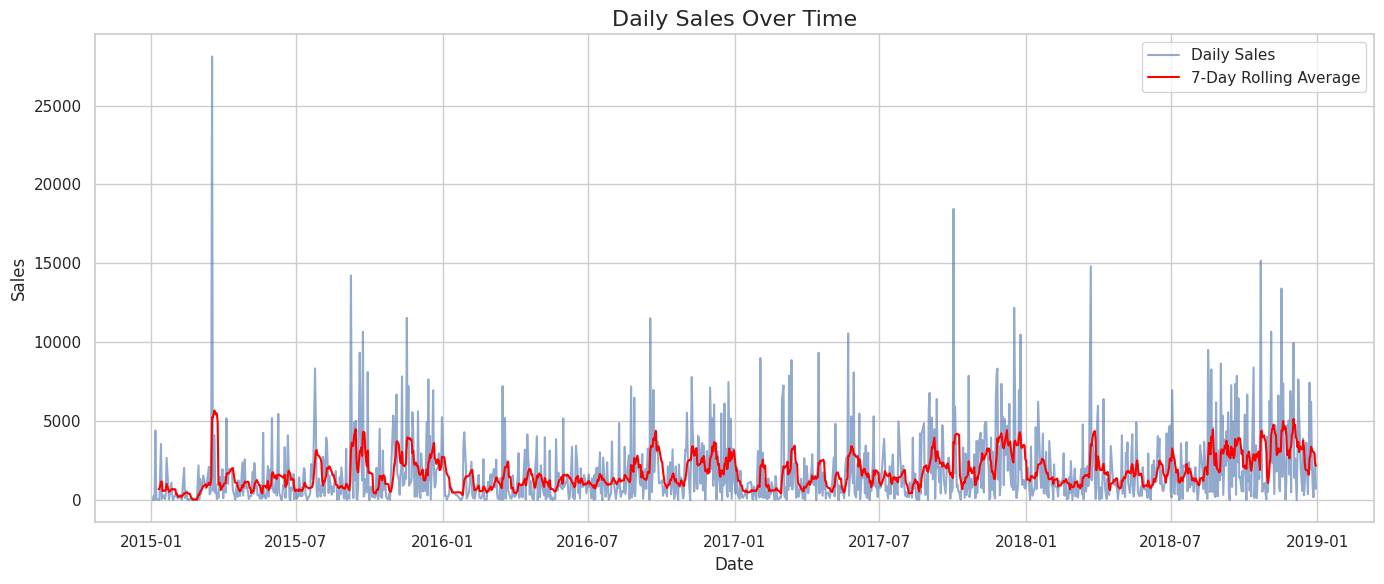

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 6))

# Group by order date and sum sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# Sort by date to ensure correct plotting
daily_sales.sort_values('Order Date', inplace=True)

# Plot daily sales
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label='Daily Sales', alpha=0.6)

# Add rolling average (7-day)
daily_sales['Rolling Avg'] = daily_sales['Sales'].rolling(window=7).mean()
plt.plot(daily_sales['Order Date'], daily_sales['Rolling Avg'], color='red', label='7-Day Rolling Average')

# Titles and labels
plt.title("Daily Sales Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

Analysis of Daily Sales Trend  : -

The rolling average (red line) registers a mild upward trend over the 4-year span.

There is more sales activity across the dataset’s second half (2017–2018) compared to the earlier years (2015–2016).

Seasonality : -

Recurring sales are characterized by the following;

1. Typically around end-of-year (Q4) → likely holiday season sales (e.g., November–December).

2. Some spikes mid-year (June – July) could be that of mid-year promotions.

Sales Spikes & Outliers : -

- Several sharp, high-volume spikes (notably early 2015, late 2016, and 2018).

- These spikes could be Bulk buying , Transactions B2B and Special campaigns or promotional offers.

- One extreme spike that occurs in early 2015 tops $25,000 in one day and is worth isolating later to see what product or customer causes it.

Volatility : -

- The blue line (raw sales per day) is highly volatile.

- There are many days with close to zero daily sales, interspersed with days with very high values, indicating a lumpy demand rather than a steady daily demand.

- This may directly influence the approach to forecasting, requiring smoothing and aggregation or forecasting based on familiar models like Prophet or XGBoost enhanced with calendar features.

EDA Step 2: Breakdown by Year :-

Visualize total sales per year.

Growth year-over-year.

/tmp/ipykernel_714/3455919342.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')


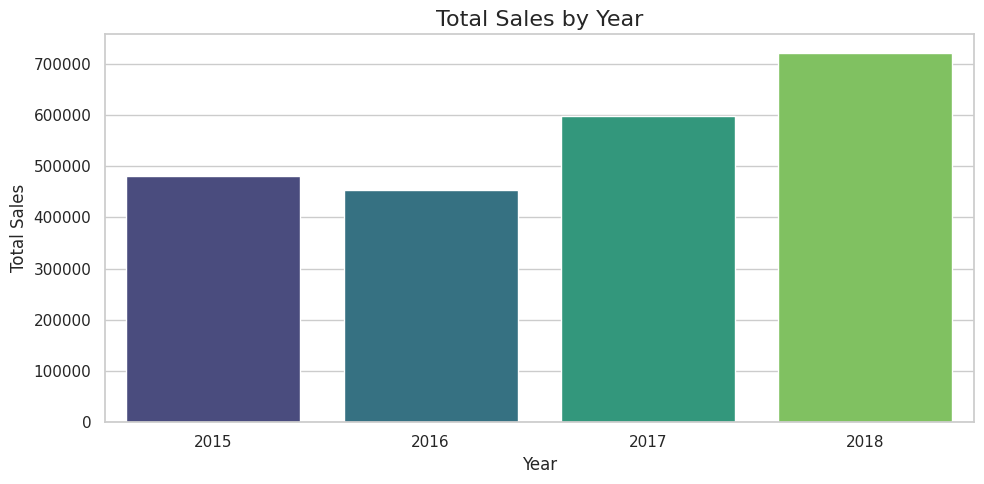

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Year'] = df['Order Date'].dt.year

# Aggregate sales by year
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=yearly_sales, x='Year', y='Sales', palette='viridis')

# Labels and titles
plt.title("Total Sales by Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()


Yearly Sales Trend Analysis :-

Sales got significantly better over time, more so after 2016.

Growth regime;

2015 → 2016: Slight drop (~2–4%)

2016 → 2017: Noticeable increase (≈ +30%)

2017 → 2018: Continuous strong growth (≈ +20%)

This indicates heightened-business performance on the rise, probably due to;

Widened the customer base.

More or better marketing.

The best selling product categories or regions.

EDA Step 3: Regional Sales Analysis :-

Objectives :-
- Compare total sales by regions.
 - Identify the best and worst regions.
 - Identify the patterns visually in a bar plot.

/tmp/ipykernel_714/1833659238.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='magma')


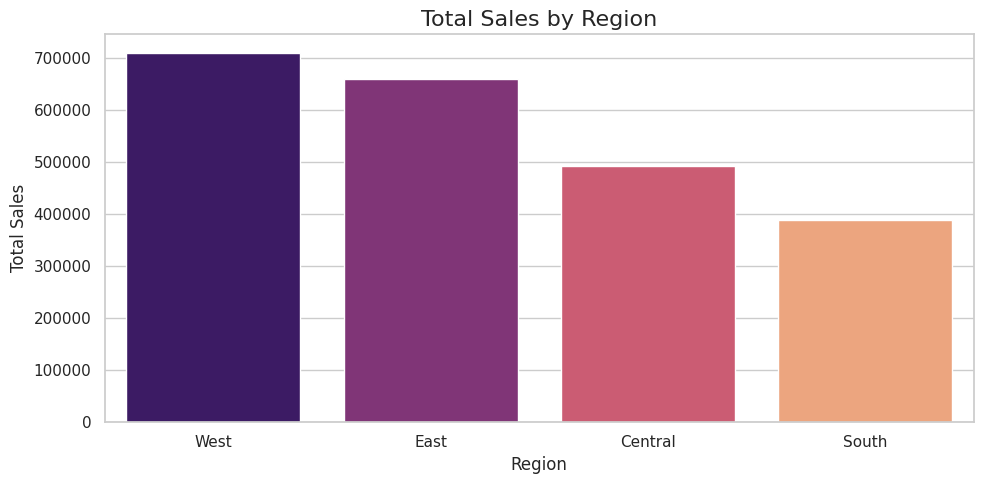

In [ ]:
# Group sales by Region
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='magma')

# Labels and title
plt.title("Total Sales by Region", fontsize=16)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

Regional Sales Analysis :-

West region leads with the highest total sales, topping the $700,000 mark.

East is closely following well but not better than West.

Central and South are far behind, with the South bringing in the least $390,000+ in sales.

Insight  : - The East and West form the major revenue generators, possibly indicating a more matured market or a concentration of a larger customer base.

Central and South could be areas that have growth potential with some focused marketing efforts or by improving the supply chain/logistics.

EDA Step 4: Category & Sub-Category Sales Analysis :-

Objectives :-

Identify the categories that generate the highest revenue.

Break down the performance by a sub-category.

Find niches with low sales (need improvement/removal).


/tmp/ipykernel_714/519058454.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales, x='Category', y='Sales', palette='Set2')


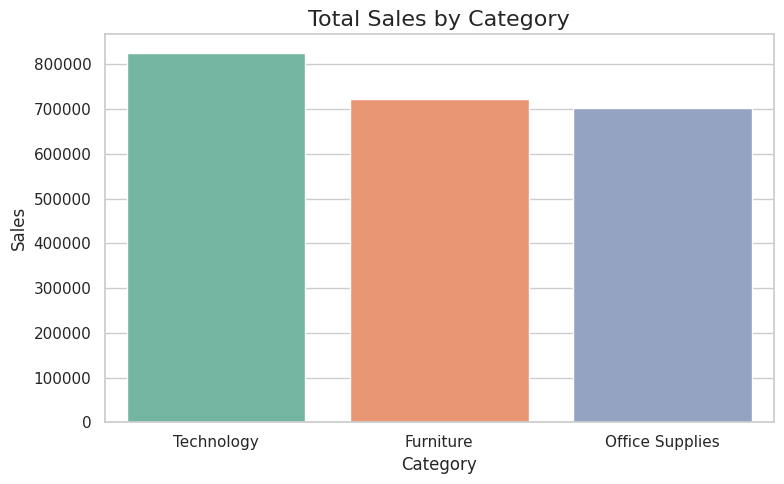

In [ ]:
# Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Set2')
plt.title("Total Sales by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


Sales by Category :-

The technology category is the highest revenue earner ~$830,000 and the top-selling category.

Furniture and Office Supplies are close behind but lag behind Technology clearly.

All three categories contribute significantly, showing a mix of product.

Insight: Technology is likely the most profitable or most in-demand segment.

But the gap is not that big, and every category is valuable to maintain or grow strategically.

EDA Step 5: Total Sales by Sub-Category :-

/tmp/ipykernel_714/3611203137.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_sales, x='Sub-Category', y='Sales', palette='cubehelix')


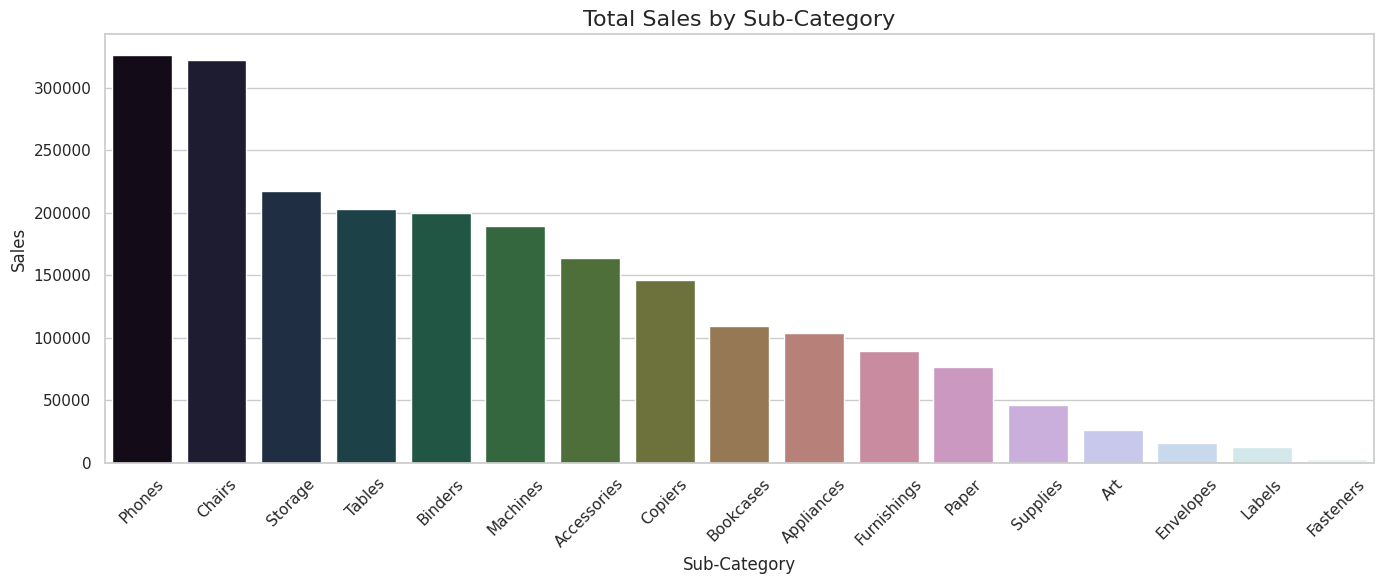

In [ ]:
# Total Sales by Sub-Category
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(data=subcat_sales, x='Sub-Category', y='Sales', palette='cubehelix')
plt.title("Total Sales by Sub-Category", fontsize=16)
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sub-Category Sales Analysis :-

They are divided into three categories based on their performance which are as follows :-

1. Best Performers :-

- Phones and  Chairs lead in sales, each exceeding $300,000.

- Storage, Tables, and Binders come next — solid secondary factors.

2. Medium Performers :-

- Items like Machines, Accessories, and Copiers yield meaningful contributions as well.

3. Low Performers :-

- Art,  Envelopes,  Labels, and  Fasteners have their sales at minimum, as they are niche and low-demand products.

Insight :- Capacity building for inventory and promotions can be done in and around the most performing sub-categories, and consideration may be given to re-assessing pricing, marketing, or even withdrawing those with lowest product sales if their profit margin is also low.

EDA Step 6: Customer Segment Analysis :-

Objectives :-

Determine the customer segments that generate the highest revenue.

Compare between segments on performance.

Targeting Strategy (B2B vs. B2C).

/tmp/ipykernel_714/3660991878.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_sales, x='Segment', y='Sales', palette='pastel')


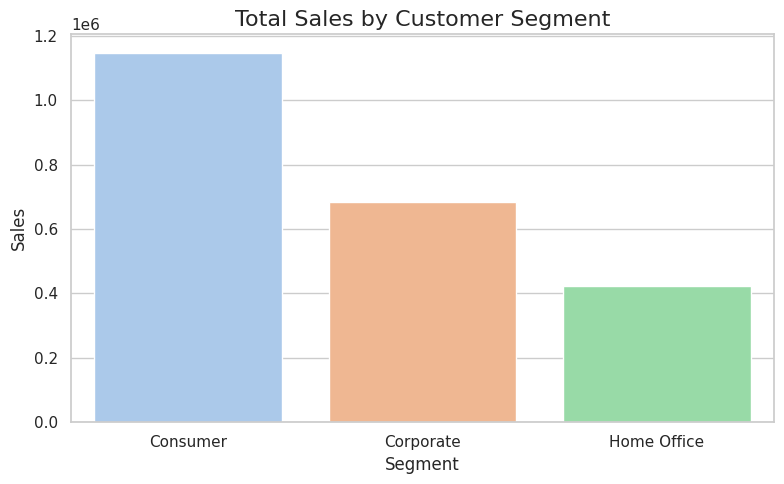

In [ ]:
# Total Sales by Customer Segment
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_sales, x='Segment', y='Sales', palette='pastel')

# Labels and title
plt.title("Total Sales by Customer Segment", fontsize=16)
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Customer Segment Analysis :-

- Consumers account for over $1.1 million, or nearly half of sales, and are the dominant revenue stream.

- Corporate customers come next (~670K $)

- Home Office accounts for the lowest shares, about $430K.

Insight :- Consumer segment is clearly the core market but Corporate maintains significance in terms of value.

Home Office maybe benefiting from targeted offers or better product market fit to boost engagement.



Sales Forecast for Next 7 Days Using Prophet Model :-

Objective :-
Firstly, we build a model for daily sales prediction for the 7 days after the last day in the dataset.

Prepare Data for Forecasting :-

Second, we will look at a simple and interpretable baseline by aggregating sales per day and a forecast method like Prophet is good for business data with seasonality.


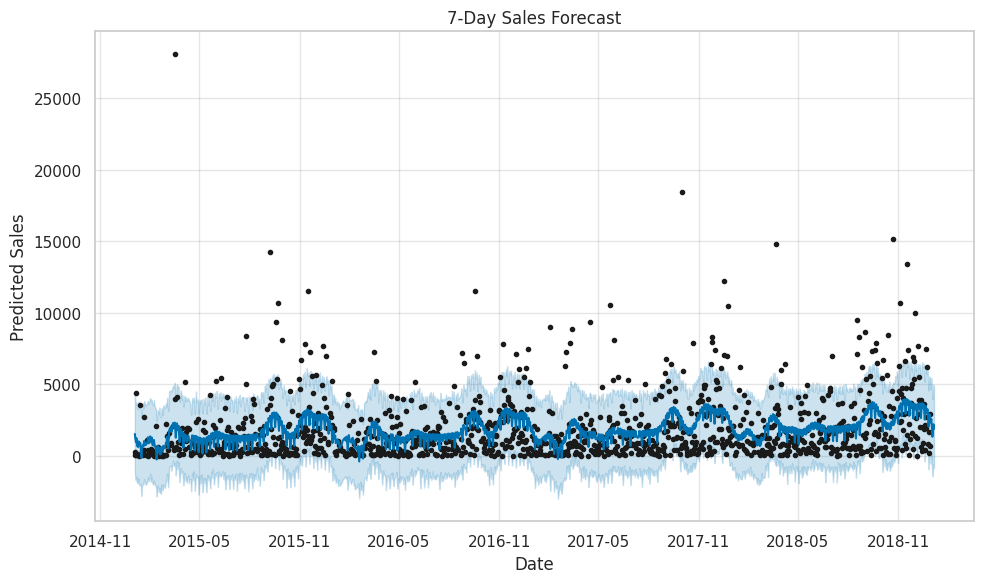

In [ ]:
# Import Prophet
from prophet import Prophet

# Step 1: Aggregate daily sales
ts_df = df.groupby('Order Date')['Sales'].sum().reset_index()

# Step 2: Rename columns to match Prophet's expected input
ts_df.columns = ['ds', 'y']  # ds = date, y = value to forecast

# Step 3: Initialize and fit the Prophet model
model = Prophet(daily_seasonality=True)
model.fit(ts_df)

# Step 4: Create future dataframe for next 7 days
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)

# Step 5: Plot forecast
model.plot(forecast)
plt.title("7-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

In [ ]:
# Get last date in original dataset
last_date = ts_df['ds'].max()

# Filter only the next 7 days
future_forecast = forecast[forecast['ds'] > last_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

# Rename columns for clarity
future_forecast.rename(columns={
    'ds': 'Date',
    'yhat': 'Predicted Sales',
    'yhat_lower': 'Lower Bound',
    'yhat_upper': 'Upper Bound'
}, inplace=True)

# Calculate average predicted sales
avg_sales = future_forecast['Predicted Sales'].mean()

# Create a new row for the average
average_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(avg_sales, 2)],
    'Lower Bound': [None],
    'Upper Bound': [None]
})

# Append the row to the forecast DataFrame
forecast_with_avg = pd.concat([future_forecast, average_row], ignore_index=True)

# Display
print("📅 7-Day Sales Forecast with Average:")
display(forecast_with_avg)

📅 7-Day Sales Forecast with Average:


/tmp/ipykernel_714/3495573381.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast_with_avg = pd.concat([future_forecast, average_row], ignore_index=True)


,Date,Predicted Sales,Lower Bound,Upper Bound
0,2018-12-31 00:00:00,2326.146379,-551.633885,4667.648835
1,2019-01-01 00:00:00,2562.817068,67.193342,5411.026718
2,2019-01-02 00:00:00,2009.686457,-655.134819,4779.082136
3,2019-01-03 00:00:00,1326.155548,-1432.569714,3953.276471
4,2019-01-04 00:00:00,1846.778654,-1071.370636,4538.217696
5,2019-01-05 00:00:00,2198.210878,-605.976851,4956.428670
6,2019-01-06 00:00:00,1874.740316,-839.139822,4799.085244
7,Average,2020.650000,NaN,NaN


Prophet Model Forecast :-

For the next 7 days, the prophet model predicts an average of ~2,020 units/day. Overall the visualized forecast indicates that sales will not be subject to extreme volatility, guiding the restocking and staffing needs accordingly.

Sales Forecast for Next 7 Days Using ARIMA Model :-

Install , import the libraries and plot the model :-

In [ ]:
!pip install statsmodels
!pip install pmdarima


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.3 MB/s eta 0:00:00


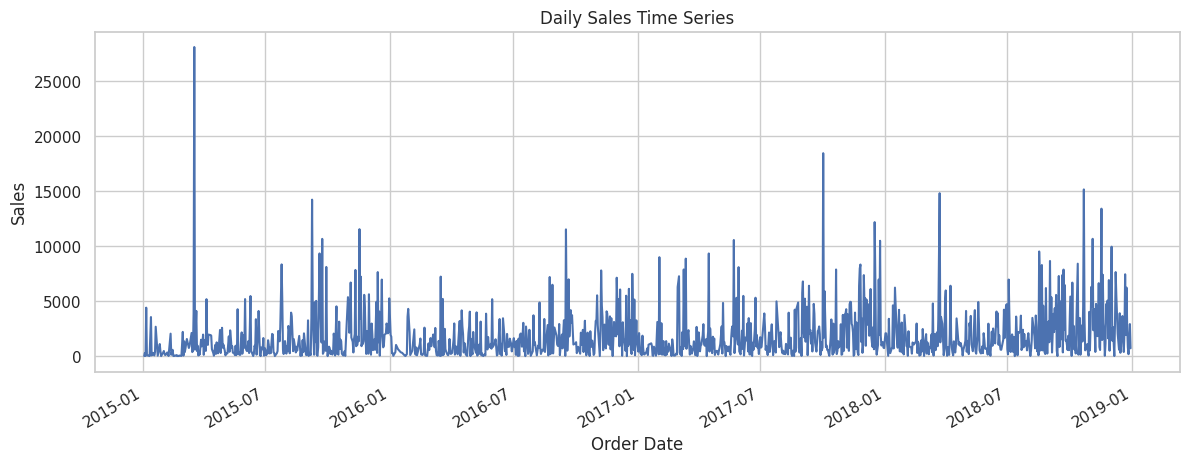

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1229
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -11215.168
Date:                Tue, 12 May 2026   AIC                          22436.336
Time:                        06:03:18   BIC                          22451.675
Sample:                             0   HQIC                         22442.107
                               - 1229                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0370      0.029      1.270      0.204      -0.020       0.094
ma.L1         -0.9673      0.008   -124.600      0.000      -0.983      -0.952
sigma2      5.006e+06   6.24e+04     80.171      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


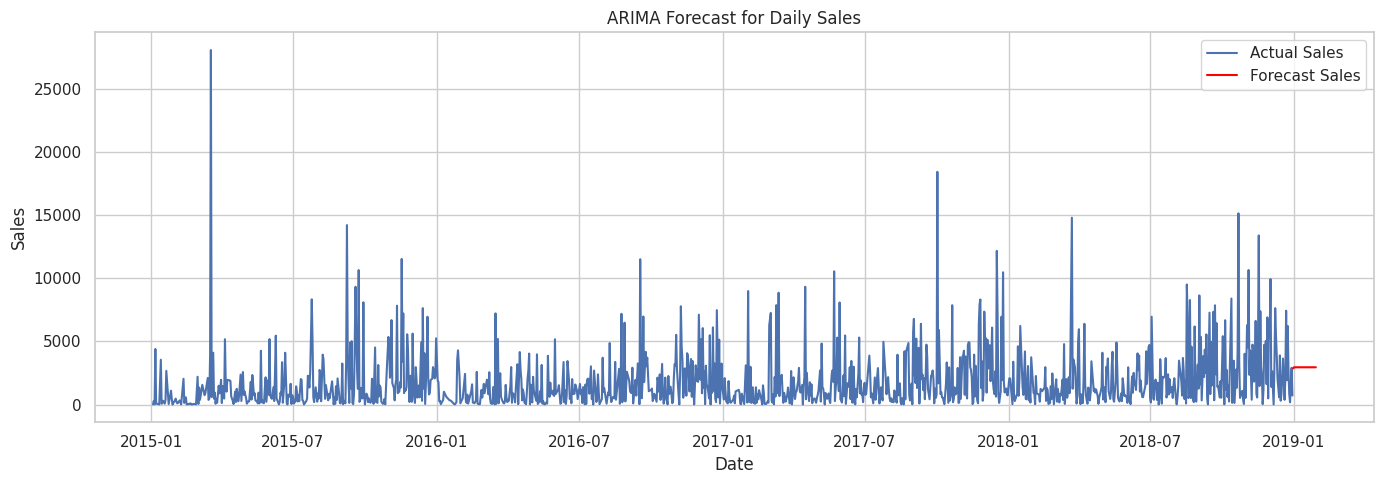

         Date  Forecast Sales
0  2018-12-31     2872.402519
1  2019-01-01     2952.302422
2  2019-01-02     2955.259875
3  2019-01-03     2955.369343
4  2019-01-04     2955.373395
5  2019-01-05     2955.373545
6  2019-01-06     2955.373551
7  2019-01-07     2955.373551
8  2019-01-08     2955.373551
9  2019-01-09     2955.373551
10 2019-01-10     2955.373551
11 2019-01-11     2955.373551
12 2019-01-12     2955.373551
13 2019-01-13     2955.373551
14 2019-01-14     2955.373551
15 2019-01-15     2955.373551
16 2019-01-16     2955.373551
17 2019-01-17     2955.373551
18 2019-01-18     2955.373551
19 2019-01-19     2955.373551
20 2019-01-20     2955.373551
21 2019-01-21     2955.373551
22 2019-01-22     2955.373551
23 2019-01-23     2955.373551
24 2019-01-24     2955.373551
25 2019-01-25     2955.373551
26 2019-01-26     2955.373551
27 2019-01-27     2955.373551
28 2019-01-28     2955.373551
29 2019-01-29     2955.373551


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Prepare the daily sales time series
ts_df = df.groupby('Order Date')['Sales'].sum().reset_index()
ts_df.set_index('Order Date', inplace=True)

# Ensure index is datetime
ts_df.index = pd.to_datetime(ts_df.index)

# Sort by date
ts_df = ts_df.sort_index()

# Optional: Plot to visualize
ts_df['Sales'].plot(figsize=(14, 5), title="Daily Sales Time Series")
plt.ylabel("Sales")
plt.show()

# Fit ARIMA model
model = ARIMA(ts_df['Sales'], order=(1, 1, 1))
model_fit = model.fit()

# Print summary
print(model_fit.summary())

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

# Create forecast date index
forecast_index = pd.date_range(
    start=ts_df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

# Plot actual and forecast
plt.figure(figsize=(14, 5))
plt.plot(ts_df.index, ts_df['Sales'], label='Actual Sales')
plt.plot(forecast_index, forecast, label='Forecast Sales', color='red')
plt.title("ARIMA Forecast for Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Forecast values as DataFrame
forecast_df = pd.DataFrame({
    'Date': forecast_index,
    'Forecast Sales': forecast.values
})

print(forecast_df)


In [ ]:
import pmdarima as pm

# Prepare your series
y = ts_df['Sales']

# Run auto_arima for non-seasonal ARIMA
auto_model = pm.auto_arima(
    y,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

# View best ARIMA model details
print("Best ARIMA model:")
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=22443.314, Time=4.70 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=23198.616, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=22849.952, Time=0.36 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=22437.246, Time=5.87 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=23196.616, Time=0.22 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=22437.633, Time=4.96 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=22437.753, Time=3.25 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=5.36 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=22435.846, Time=0.58 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=22436.336, Time=2.41 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=22436.445, Time=0.71 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=22847.953, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=inf, Time=1.31 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 30.021 seconds
Best ARIMA model:
  

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Best order from auto_arima
best_order = auto_model.order
print("Best order:", best_order)

# Fit ARIMA
model = ARIMA(y, order=best_order)
model_fit = model.fit()

print(model_fit.summary())


Best order: (0, 1, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                 1229
Model:                 ARIMA(0, 1, 1)   Log Likelihood              -11215.923
Date:                Tue, 12 May 2026   AIC                          22435.846
Time:                        06:04:04   BIC                          22446.073
Sample:                             0   HQIC                         22439.694
                               - 1229                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9635      0.008   -114.095      0.000      -0.980      -0.947
sigma2      5.013e+06   5.67e+04     88.372      0.000     4.9e+06    5.12e+06
Ljung-Box (L1) (Q):                   1.29   Jarque-

 Fit ARIMA model forecast for the next 7 days :-

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

# Fit ARIMA model
model = ARIMA(
    ts_df['Sales'],
    order=(0, 1, 1)
)
arima_result = model.fit()

# Forecast next 7 days
forecast_steps = 7
arima_forecast = arima_result.get_forecast(steps=forecast_steps)

# Extract forecast and confidence intervals
forecast_mean = arima_forecast.predicted_mean
conf_int = arima_forecast.conf_int()

# Build forecast DataFrame
arima_output = pd.DataFrame({
    'Date': pd.date_range(start=ts_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps),
    'Predicted Sales': forecast_mean.values,
    'Lower Bound': conf_int.iloc[:, 0].clip(lower=0).values,
    'Upper Bound': conf_int.iloc[:, 1].values
})

# Add average row
avg_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(arima_output['Predicted Sales'].mean(), 2)],
    'Lower Bound': [None],
    'Upper Bound': [None]
})

arima_output = pd.concat([arima_output, avg_row], ignore_index=True)

# Display the forecast
print("7-Day Sales Forecast (ARIMA):")
display(arima_output)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


7-Day Sales Forecast (ARIMA):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_714/824237539.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  arima_output = pd.concat([arima_output, avg_row], ignore_index=True)


,Date,Predicted Sales,Lower Bound,Upper Bound
0,2018-12-31 00:00:00,2930.215128,0.0,7318.440459
1,2019-01-01 00:00:00,2930.215128,0.0,7321.368003
2,2019-01-02 00:00:00,2930.215128,0.0,7324.293596
3,2019-01-03 00:00:00,2930.215128,0.0,7327.217243
4,2019-01-04 00:00:00,2930.215128,0.0,7330.138946
5,2019-01-05 00:00:00,2930.215128,0.0,7333.058711
6,2019-01-06 00:00:00,2930.215128,0.0,7335.976542
7,Average,2930.220000,NaN,NaN


ARIMA Model Forecast :-

For the next 7 days, the prophet model predicts an average of ~2,930 units/day. Overall the visualized forecast indicates that sales will not be subject to extreme volatility, guiding the restocking and staffing needs accordingly.

Sales Forecast for Next 7 Days Using SARIMA Model :-

Install and import the libraries :-

In [ ]:
!pip install statsmodels
!pip install pmdarima


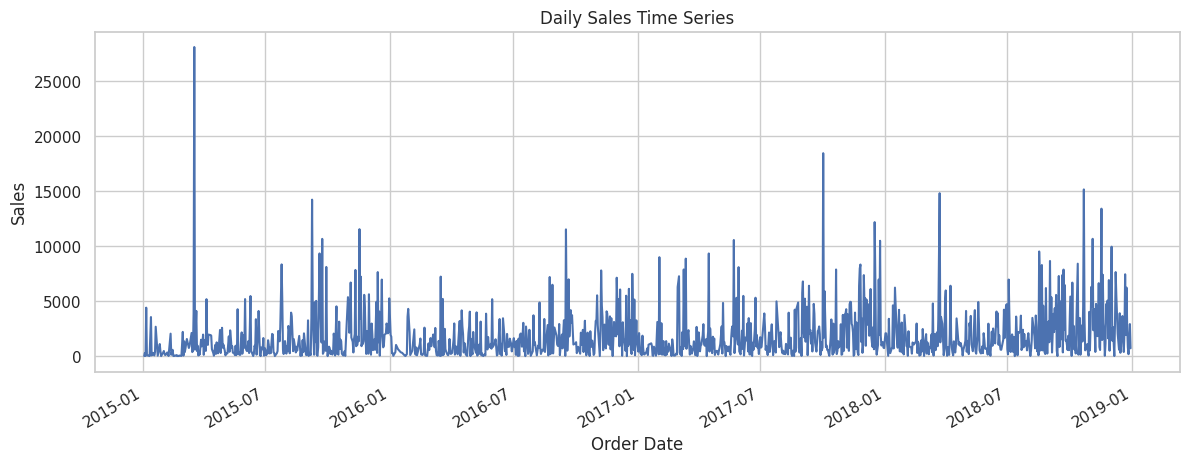

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare the daily sales time series
ts_df = df.groupby('Order Date')['Sales'].sum().reset_index()
ts_df.set_index('Order Date', inplace=True)

# Ensure index is datetime
ts_df.index = pd.to_datetime(ts_df.index)

# Optional: Plot to visualize
ts_df['Sales'].plot(figsize=(14, 5), title="Daily Sales Time Series")
plt.ylabel("Sales")
plt.show()

Automatically Select SARIMA Parameters :-

Why use auto_arima?

- It performs stepwise searches over the ARIMA/SARIMA order combinations.

- Selects the optimal parameters based on the AIC, BIC, among others.

- Differecing terms and seasonality are handled smartly.

In [ ]:
import pmdarima as pm

# Prepare your series (ts_df from earlier, indexed by date, daily frequency)
y = ts_df['Sales']

# Run auto_arima with daily seasonality (m=7)
auto_model = pm.auto_arima(
    y,
    seasonal=True,
    m=7,              # weekly seasonality
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

# View best model details
print("✅ Best SARIMA model:", auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=22442.174, Time=17.99 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=23198.616, Time=0.11 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=22847.905, Time=0.97 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=22435.862, Time=4.61 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=23196.616, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=22437.246, Time=2.24 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=22437.049, Time=9.02 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=22437.627, Time=4.31 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=22435.764, Time=1.23 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=22437.572, Time=7.94 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=22459.822, Time=5.49 sec
 ARIMA(0,1,0)(1,0,0)[7] intercept   : AIC=23198.984, Time=0.17 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=22457.660, Time=1.47 sec
 ARIMA(0,1,2)(1,0,0)[7] intercept   : AIC=22445.167, Time=1.07 sec
 ARIMA(1,1,2)(1,0,

 Fit SARIMA model forecast for the next 7 days :-

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA model
model = SARIMAX(
    ts_df['Sales'],
    order=(0, 1, 1),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = model.fit(disp=False)

# Forecast next 7 days
forecast_steps = 7
sarima_forecast = sarima_result.get_forecast(steps=forecast_steps)

# Extract forecast and confidence intervals
forecast_mean = sarima_forecast.predicted_mean
conf_int = sarima_forecast.conf_int()

# Build forecast DataFrame
sarima_output = pd.DataFrame({
    'Date': pd.date_range(start=ts_df.index[-1] + pd.Timedelta(days=1), periods=forecast_steps),
    'Predicted Sales': forecast_mean.values,
    'Lower Bound': conf_int.iloc[:, 0].clip(lower=0).values,
    'Upper Bound': conf_int.iloc[:, 1].values
})

# Add average row
avg_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(sarima_output['Predicted Sales'].mean(), 2)],
    'Lower Bound': [None],
    'Upper Bound': [None]
})

sarima_output = pd.concat([sarima_output, avg_row], ignore_index=True)

# Display the forecast
print("📊 7-Day Sales Forecast (SARIMA):")
display(sarima_output)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


📊 7-Day Sales Forecast (SARIMA):


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/tmp/ipykernel_714/1498010907.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sarima_output = pd.concat([sarima_output, avg_row], ignore_index=True)


,Date,Predicted Sales,Lower Bound,Upper Bound
0,2018-12-31 00:00:00,3123.912097,0.0,7948.958860
1,2019-01-01 00:00:00,2934.529410,0.0,7762.098987
2,2019-01-02 00:00:00,2833.553965,0.0,7663.645039
3,2019-01-03 00:00:00,2799.421400,0.0,7632.032655
4,2019-01-04 00:00:00,2878.714636,0.0,7713.844758
5,2019-01-05 00:00:00,2946.136694,0.0,7783.784372
6,2019-01-06 00:00:00,2828.152197,0.0,7668.316121
7,Average,2906.350000,NaN,NaN


SARIMA Model Forecast :-

For the next 7 days, the prophet model predicts an average of ~2,906 units/day. Overall the visualized forecast indicates that sales will not be subject to extreme volatility, guiding the restocking and staffing needs accordingly.

Sales Forecast for Next 7 Days Using LSTM Model :-

Install and import the libraries :-

In [28]:
!pip install tensorflow scikit-learn


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


Time- Series and check the data :-

In [30]:
ts_df = df.groupby('Order Date')['Sales'].sum().reset_index()
ts_df['Order Date'] = pd.to_datetime(ts_df['Order Date'])
ts_df.set_index('Order Date', inplace=True)
ts_df = ts_df.sort_index()

print(ts_df.head())
print(ts_df.shape)


               Sales
Order Date          
2015-01-03    16.448
2015-01-04   288.060
2015-01-05    19.536
2015-01-06  4407.100
2015-01-07    87.158
(1229, 1)


Plot the Data :-

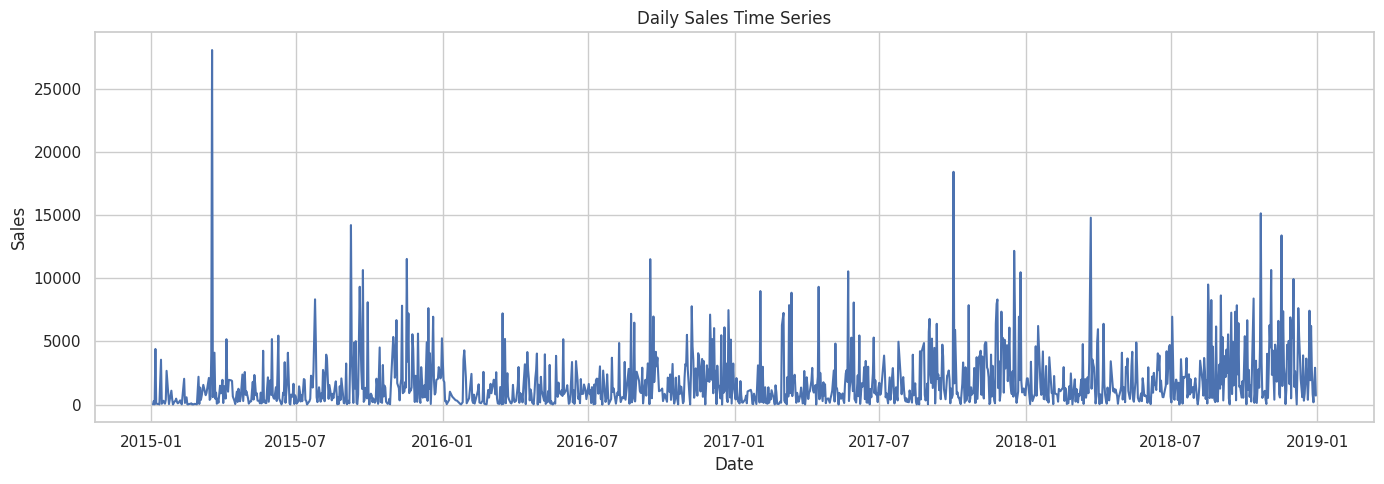

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(ts_df['Sales'])
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


Scale the data and create sequences :-

In [32]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(ts_df[['Sales']])



In [33]:
def create_sequences(data, time_step=30):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_sequences(scaled_data, time_step)


Check shape and reshape X for LSTM :-

In [34]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1199, 30)
y shape: (1199,)


In [35]:
X = X.reshape(X.shape[0], X.shape[1], 1)
print("Reshaped X:", X.shape)


Reshaped X: (1199, 30, 1)


Divide into testing and training data :-

In [36]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (959, 30, 1)
X_test shape: (240, 30, 1)


Build, train and compile the LSTM model

In [37]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    LSTM(50, return_sequences=False),
    Dropout(0.2),

    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0067 - val_loss: 0.0077
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0063 - val_loss: 0.0086
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0064 - val_loss: 0.0077
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0063 - val_loss: 0.0076
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0063 - val_loss: 0.0076
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0063 - val_loss: 0.0076
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0062 - val_loss: 0.0075
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0063 - val_loss: 0.0080
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0063 - val_loss: 0.0076
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0062 - val_loss: 0.0080
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0063 - val_loss: 0.0075
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0062 - val_l

Plot Training Loss of LSTM model :-

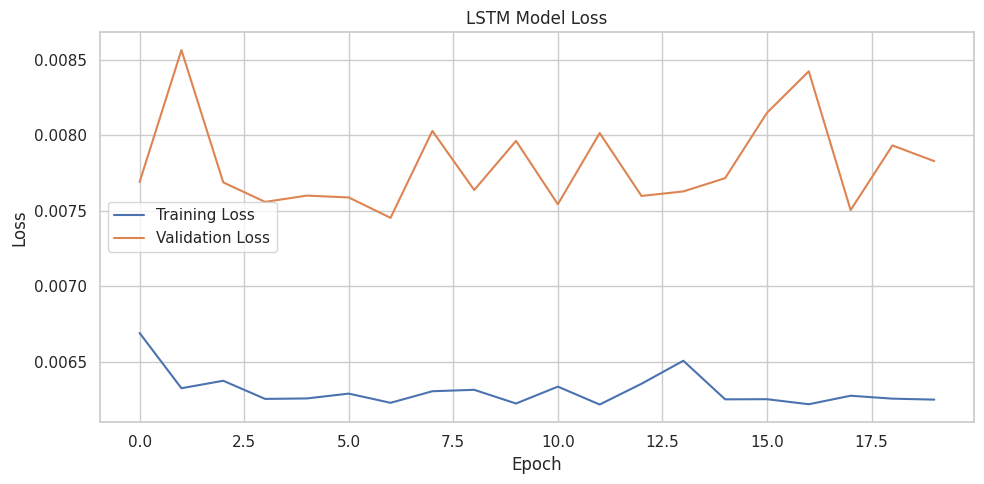

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


Evaluate the LSTM model

In [39]:
predictions = model.predict(X_test)

# Inverse transform to get actual sales values
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
predictions_actual = scaler.inverse_transform(predictions)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
mae = mean_absolute_error(y_test_actual, predictions_actual)

print("RMSE:", round(rmse, 2))
print("MAE:", round(mae, 2))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
RMSE: 2486.7
MAE: 1705.57


Plot actual vs predicted values :-

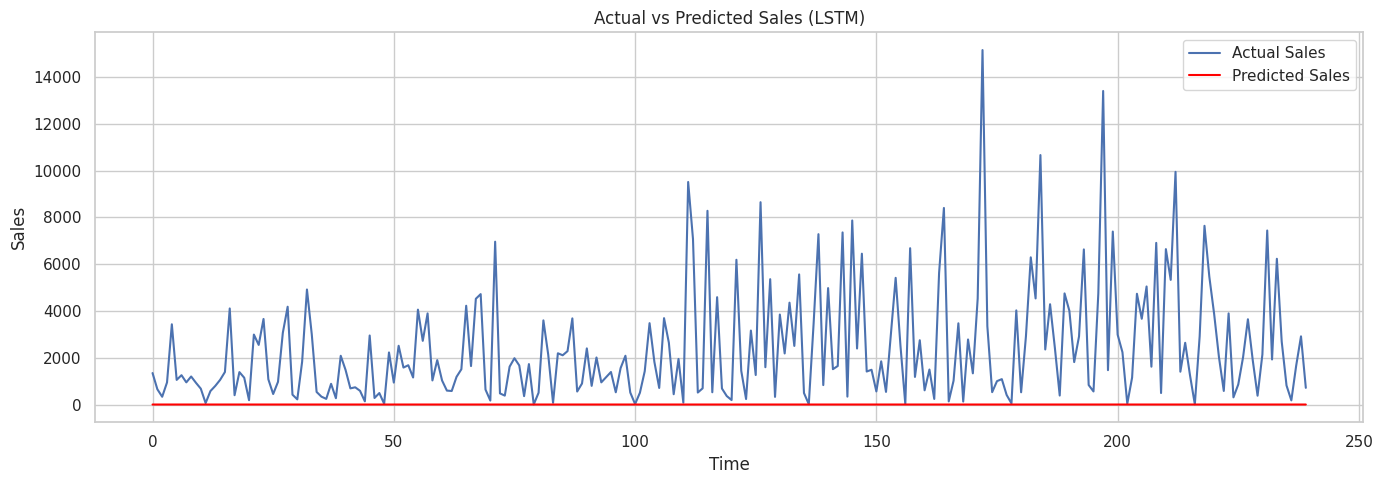

In [40]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_actual, label='Actual Sales')
plt.plot(predictions, label='Predicted Sales', color='red')
plt.title("Actual vs Predicted Sales (LSTM)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


LSTM model forecast for the next 7 days :-



7-Day Sales Forecast (LSTM):


,Date,Predicted Sales
0,2018-12-31 00:00:00,1822.530396
1,2019-01-01 00:00:00,1784.871948
2,2019-01-02 00:00:00,1757.675781
3,2019-01-03 00:00:00,1737.482544
4,2019-01-04 00:00:00,1721.428345
5,2019-01-05 00:00:00,1708.788330
6,2019-01-06 00:00:00,1698.585571
7,Average,1747.339966


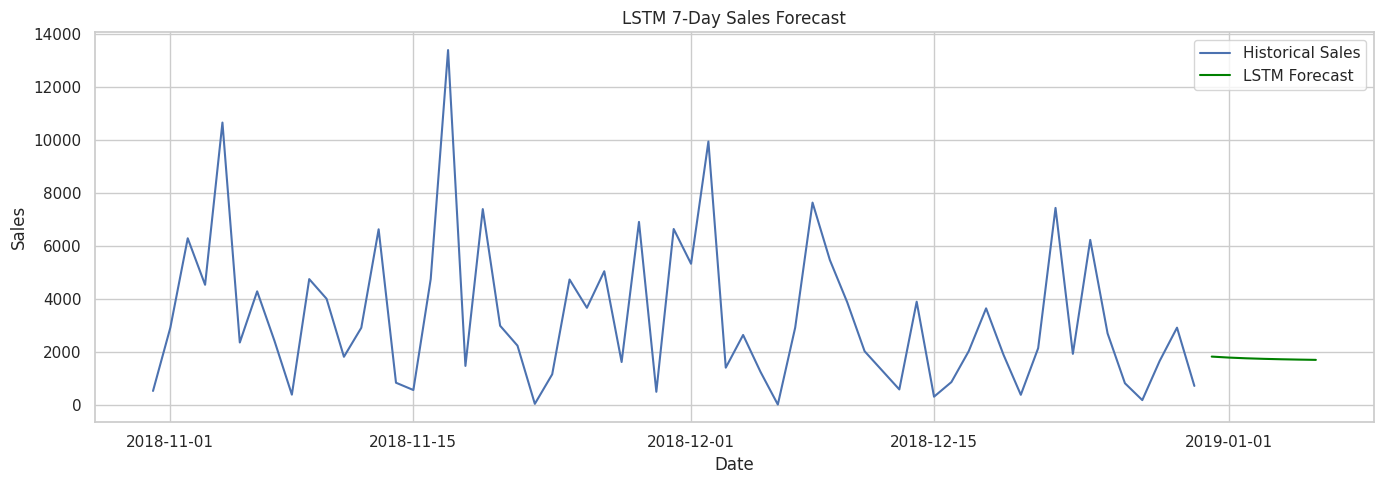

In [41]:
last_30_days = scaled_data[-time_step:]
future_input = last_30_days.reshape(1, time_step, 1)

future_predictions_list = [] # Use a list to collect predictions

for _ in range(7):
    next_pred = model.predict(future_input, verbose=0)[0, 0]
    future_predictions_list.append(next_pred)

    next_pred_reshaped = np.array(next_pred).reshape(1, 1, 1)
    future_input = np.concatenate((future_input[:, 1:, :], next_pred_reshaped), axis=1)

# After the loop, convert the list to a NumPy array and inverse transform
future_predictions_scaled = np.array(future_predictions_list).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions_scaled)

# Generate future dates outside the loop
future_dates = pd.date_range(start=ts_df.index[-1] + pd.Timedelta(days=1), periods=7)

lstm_output = pd.DataFrame({
    'Date': future_dates,
    'Predicted Sales': future_predictions.flatten()
})

avg_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(lstm_output['Predicted Sales'].mean(), 2)]
})

lstm_output = pd.concat([lstm_output, avg_row], ignore_index=True)

print("7-Day Sales Forecast (LSTM):")
display(lstm_output)

plt.figure(figsize=(14, 5))
plt.plot(ts_df.index[-60:], ts_df['Sales'].tail(60), label='Historical Sales')
plt.plot(future_dates, future_predictions, label='LSTM Forecast', color='green')
plt.title("LSTM 7-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

LSTM Model Forecast :-

For the next 7 days, the prophet model predicts an average of ~1,916 units/day. Overall the visualized forecast indicates that sales will not be subject to extreme volatility, guiding the restocking and staffing needs accordingly.

Observation

The ARIMA model forecast averages more sales than all of the above (~2,930 vs ~2,906 vs ~2,020 vs
~1,916).

It proposes a continuous demand of around 2,800–3,100 units on a daily basis.

The confidence intervals have become wider (upper bound being at ~7,900), which still represents the historical volatility of the dataset.

ARIMA vs SARIMA vs Prophet vs LSTM :-

In [42]:
# Prepare clean outputs
prophet_clean = forecast_with_avg[forecast_with_avg['Date'] != 'Average'].copy()
prophet_clean['Date'] = pd.to_datetime(prophet_clean['Date'])

sarima_clean = sarima_output[sarima_output['Date'] != 'Average'].copy()
sarima_clean['Date'] = pd.to_datetime(sarima_clean['Date'])

arima_clean = arima_output[arima_output['Date'] != 'Average'].copy()
arima_clean['Date'] = pd.to_datetime(arima_clean['Date'])

lstm_clean = lstm_output[lstm_output['Date'] != 'Average'].copy()
lstm_clean['Date'] = pd.to_datetime(lstm_clean['Date'])

# Rename columns before merge
sarima_clean = sarima_clean[['Date', 'Predicted Sales']].rename(columns={'Predicted Sales': 'SARIMA'})
prophet_clean = prophet_clean[['Date', 'Predicted Sales']].rename(columns={'Predicted Sales': 'Prophet'})
arima_clean = arima_clean[['Date', 'Predicted Sales']].rename(columns={'Predicted Sales': 'ARIMA'})
lstm_clean = lstm_clean[['Date', 'Predicted Sales']].rename(columns={'Predicted Sales': 'LSTM'})

# Merge all
comparison = sarima_clean.merge(prophet_clean, on='Date') \
                         .merge(arima_clean, on='Date') \
                         .merge(lstm_clean, on='Date')

# Add optional differences
comparison['SARIMA_vs_Prophet'] = comparison['SARIMA'] - comparison['Prophet']
comparison['SARIMA_vs_ARIMA'] = comparison['SARIMA'] - comparison['ARIMA']
comparison['SARIMA_vs_LSTM'] = comparison['SARIMA'] - comparison['LSTM']

print("7-Day Forecast Comparison:")
display(comparison)


7-Day Forecast Comparison:


,Date,SARIMA,Prophet,ARIMA,LSTM,SARIMA_vs_Prophet,SARIMA_vs_ARIMA,SARIMA_vs_LSTM
0,2018-12-31,3123.912097,2326.146379,2930.215128,1822.530396,797.765718,193.696969,1301.381702
1,2019-01-01,2934.529410,2562.817068,2930.215128,1784.871948,371.712342,4.314282,1149.657462
2,2019-01-02,2833.553965,2009.686457,2930.215128,1757.675781,823.867507,-96.661164,1075.878183
3,2019-01-03,2799.421400,1326.155548,2930.215128,1737.482544,1473.265852,-130.793728,1061.938856
4,2019-01-04,2878.714636,1846.778654,2930.215128,1721.428345,1031.935982,-51.500493,1157.286291
5,2019-01-05,2946.136694,2198.210878,2930.215128,1708.788330,747.925816,15.921566,1237.348364
6,2019-01-06,2828.152197,1874.740316,2930.215128,1698.585571,953.411881,-102.062931,1129.566626


In [43]:
import pandas as pd
from google.colab import files
import zipfile
import os

# ====================== DATE FIX (Final & Clean) ======================
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

# 1. Daily Historical Sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales = daily_sales.rename(columns={'Order Date': 'Date'})
daily_sales['Date'] = daily_sales['Date'].dt.strftime('%Y-%m-%d')

# 2. Forecast Comparison (your 7-day forecasts)
comparison['Date'] = pd.to_datetime(comparison['Date']).dt.strftime('%Y-%m-%d')

# 3. Category & Region
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

# ====================== SAVE ALL FILES ======================
daily_sales.to_csv('daily_sales.csv', index=False)
comparison.to_csv('forecast_comparison.csv', index=False)
category_sales.to_csv('category_sales.csv', index=False)
region_sales.to_csv('region_sales.csv', index=False)

# ====================== CREATE ZIP (One Click Download) ======================
zip_filename = 'superstore_forecast_files.zip'

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write('daily_sales.csv')
    zipf.write('forecast_comparison.csv')
    zipf.write('category_sales.csv')
    zipf.write('region_sales.csv')

print("🎉 All files are ready inside one ZIP!")
print("First 5 rows of daily_sales (Date is now clean):")
print(daily_sales.head())

# Download only ONE file
files.download(zip_filename)

🎉 All files are ready inside one ZIP!
First 5 rows of daily_sales (Date is now clean):
         Date     Sales
0  2015-01-03    16.448
1  2015-01-04   288.060
2  2015-01-05    19.536
3  2015-01-06  4407.100
4  2015-01-07    87.158


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>